In [29]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)
np.random.seed(2022)
tf.random.set_seed(2022)


TensorFlow version: 2.20.0


In [30]:
import pandas as pd

X, y = make_classification(
    n_samples= 5000,
    n_features=8,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=2,
    random_state=2022
)

feature_names = [
    'Income', 'Age', 'Savings', 'Credit score',
    'Number of past loans', 'Number of past loans accepted',
    'Number of past loans denied', 'Investment'
]

X_df = pd.DataFrame(X, columns=feature_names);

# Ensure 'Age' feature is not negative (or is above a certain threshold)
min_age_current = X_df['Age'].min()
if min_age_current < 25:
    X_df['Age'] = X_df['Age'] + (25 - min_age_current) # Shift all ages up so the minimum becomes 25

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y,
    test_size=0.25,
    random_state=2022,
    stratify=y
)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape,  "y_test shape:", y_test.shape)
print("Class counts (0 then 1):", np.bincount(y))
print("\nFirst 5 rows of X_train with named features:")
display(X_train.head())
print("\nMinimum Age in X_train:", X_train['Age'].min())
print("Minimum Age in X_test:", X_test['Age'].min())

X_train shape: (3750, 8) y_train shape: (3750,)
X_test shape: (1250, 8) y_test shape: (1250,)
Class counts (0 then 1): [2508 2492]

First 5 rows of X_train with named features:


,Income,Age,Savings,Credit score,Number of past loans,Number of past loans accepted,Number of past loans denied,Investment
1634,-2.506906,34.103628,-4.415804,-2.145403,1.751528,-0.518114,-2.714719,0.719003
1597,2.253705,31.591510,0.964524,2.713464,-0.147613,-3.200306,2.535539,1.325569
3687,-2.091844,32.222088,-0.996756,-1.888003,-0.303039,2.029648,-1.519429,-2.351907
4909,-0.120944,31.994425,0.748321,-0.898697,0.978450,-0.310338,-0.653533,0.361736
2913,-2.424920,31.245831,1.731331,-1.480247,1.499362,0.233780,0.059880,-1.689609



Minimum Age in X_train: 25.0
Minimum Age in X_test: 26.288536773499267


In [31]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train mean (first 3 features):", X_train_s.mean(axis=0)[:3])
print("Train std  (first 3 features):", X_train_s.std(axis=0)[:3])


Train mean (first 3 features): [-1.32634644e-17  1.55940446e-15 -8.05281767e-18]
Train std  (first 3 features): [1. 1. 1.]


In [32]:
def entropy_binary(p):
    # p is probability of class 1
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

for p in [0.5, 0.9, 0.99, 0.1]:
    print(f"p={p:>4} -> entropy={entropy_binary(p):.4f}")


p= 0.5 -> entropy=0.6931
p= 0.9 -> entropy=0.3251
p=0.99 -> entropy=0.0560
p= 0.1 -> entropy=0.3251


In [33]:
def softmax(scores):
    scores = np.array(scores, dtype=float)
    scores = scores - np.max(scores)  # stability trick
    exp_vals = np.exp(scores)
    return exp_vals / np.sum(exp_vals)

scores = [0.25, 1.23, -0.8]
probs = softmax(scores)

print("Scores:", scores)
print("Softmax probabilities:", probs)
print("Sum:", probs.sum())
print("Predicted class index:", np.argmax(probs))


Scores: [0.25, 1.23, -0.8]
Softmax probabilities: [0.2491036  0.66372565 0.08717075]
Sum: 1.0
Predicted class index: 1


In [34]:
pred = np.array([0.4, 0.3, 0.1])  # predicted probabilities
target = np.array([1, 0, 0])     # one hot: correct class is index 0

# Full formula
loss_full = -np.sum(target * np.log(np.clip(pred, 1e-12, 1 - 1e-12)))

correct_index = 0
loss_shortcut = -np.log(np.clip(pred[correct_index], 1e-12, 1 - 1e-12))

print("Cross entropy (full):", loss_full)
print("Cross entropy (shortcut):", loss_shortcut)


Cross entropy (full): 0.916290731874155
Cross entropy (shortcut): 0.916290731874155


In [35]:
softmax_outputs = np.array([
    [0.4, 0.3, 0.1],
    [0.2, 0.5, 0.3],
    [0.04, 0.8, 0.03]
])

class_targets = np.array([0, 1, 1])

neg_log = -np.log(np.clip(softmax_outputs[np.arange(len(softmax_outputs)), class_targets], 1e-12, 1 - 1e-12))
avg_loss = np.mean(neg_log)

print("Negative log per sample:", neg_log)
print("Average loss:", avg_loss)


Negative log per sample: [0.91629073 0.69314718 0.22314355]
Average loss: 0.6108604879161034


In [36]:
pred_classes = np.argmax(softmax_outputs, axis=1)
acc = np.mean(pred_classes == class_targets)

print("Predicted classes:", pred_classes)
print("True classes     :", class_targets)
print("Accuracy:", acc)


Predicted classes: [0 1 1]
True classes     : [0 1 1]
Accuracy: 1.0


In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(X_train_s.shape[1],)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)


In [39]:
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_test_s, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Final train accuracy:", history.history["accuracy"][-1])
print("Final test  accuracy:", history.history["val_accuracy"][-1])


Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7389 - loss: 0.5742 - val_accuracy: 0.8384 - val_loss: 0.4806
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8523 - loss: 0.3963 - val_accuracy: 0.8688 - val_loss: 0.3412
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8808 - loss: 0.3015 - val_accuracy: 0.8928 - val_loss: 0.2802
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9059 - loss: 0.2507 - val_accuracy: 0.9152 - val_loss: 0.2371
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9232 - loss: 0.2176 - val_accuracy: 0.9256 - val_loss: 0.2077
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9304 - loss: 0.1978 - val_accuracy: 0.9336 - val_loss: 0.1885
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9352 - loss: 0.1854 - val_accuracy: 0.9416 - val_loss: 0.1756
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9381 - loss: 0.1767 - val_accuracy: 0.

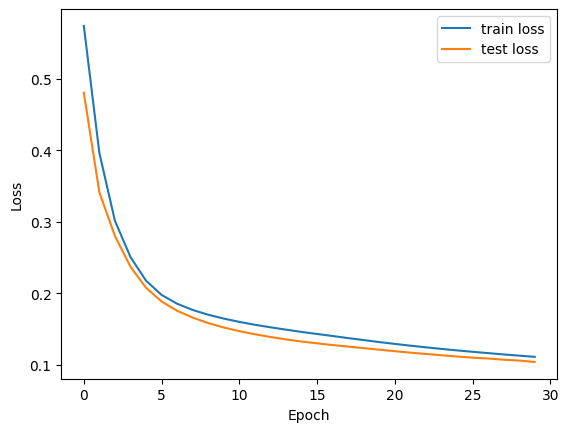

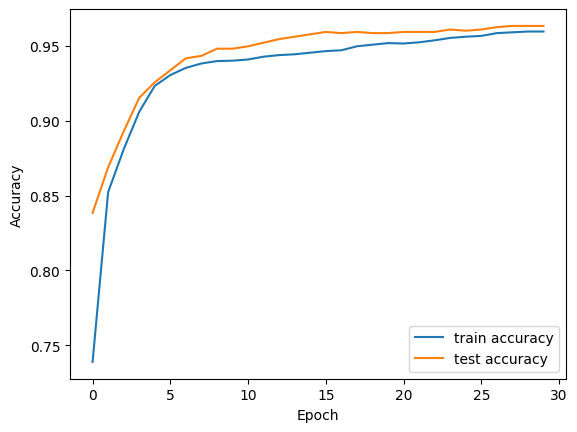

In [40]:
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### What does cross entropy tell us about wrong loan predictions?
Cross entropy measures the dissimilarity between the predicted probability and the actual outcome; a higher value for wrong predictions indicates the model was confidently incorrect.

### Why is Sigmoid used in the last layer?
Sigmoid is used in the last layer for binary classification to output a probability score between 0 and 1, representing the likelihood of the positive class.

### What would happen if we used a very large learning rate?
A very large learning rate can cause the model to overshoot the optimal solution, leading to instability, oscillations, or even divergence of the training process.

### Why is Adam better than basic Gradient Descent here?
Adam is often better than basic Gradient Descent because it adaptively adjusts the learning rate for each parameter, leading to faster convergence and more robust performance in many scenarios.